# Project Business Statistics: E-news Express


## Define Problem Statement and Objectives

**Problem Statement:**
* E-news Express, an online news portal has seen a decline in new subscribers in the current year as compared to the past year.
* This is attributed to the current webpage which is not designed to be engaging enough for customers to subscribe.

**Objectives:**
* E-news Express aims to expand its business by acquiring new subscribers by performing an experiment (determine the effectiveness of the newly designed landing page) by:
  * Assessing if users spend more time on the new landing page or the old landing page.
  * Assessing if users who visit the new landing page are more likely to become subscribers as compared with the old landing page.
  * Assessing if the users preferred language has an impact on their likelihood to become subcribers.
  * Assessing if the users preferred language has an impact on the time they spend on the new landing page.



## Import all the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
#this code imports the necessary libraries for data manipulation
import numpy as np
import pandas as pd

#this code imports the necessary libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#this code imports the necessary library for statistical analysis
from scipy import stats

## Reading the Data into a DataFrame

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Python Course/Module 2/Project/abtest.csv') # this code reads the csv file referenced in the parenthesis.

## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [ ]:
df.head() # this code returns the first 5 rows in the dataset.

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [ ]:
df.tail() # this code returns the last 5 rows in the dataset.

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [ ]:
df.shape # this code checks the number of rows and columns in the data

(100, 6)

In [ ]:
df.info() # this code checks the datatype of each column, the total rows and columns, and the memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [ ]:
df.describe().T #this code checks the statistical summary of the numeric variables

,count,mean,std,min,25%,50%,75%,max
user_id,100.0,546517.0000,52.295779,546443.00,546467.75,546492.500,546567.2500,546592.00
time_spent_on_the_page,100.0,5.3778,2.378166,0.19,3.88,5.415,7.0225,10.71


In [ ]:
df.describe(include='object').T #this code checks the statistical summary of the categorical variables

,count,unique,top,freq
group,100,2,control,50
landing_page,100,2,old,50
converted,100,2,yes,54
language_preferred,100,3,Spanish,34


In [ ]:
df.isnull().sum() # this code returns the sum after replacing all the values in the data with the boolean values 'True' if there are missing values such as NAN or none
                  # it returns the sum of null values in the data.

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]/df.shape[0]*100 # this code returns the percentage of missing values in the data.

,0


In [ ]:
df.duplicated().sum() #this code checks for duplicates in the data and sums them

np.int64(0)


#### Observations:

* *There are 100 rows and 6 columns in the dataset. Of these columns, 2 are numeric (columns with index 0 and 3), and 4 are object type (columns with index 1, 2, 4 and 5).*

* *It appears that all columns are of the appropriate datatype.*

* *Statistical Summary*

  * *Time Spent on the Page*
    * *The minimum amount of time spent on a page is about 0.19 minutes and the maximun amount of time is 10.71 (11) minutes. A user spends an average time of about 5.4 minutes on a page.*
  * *Group*
    * *There are 2 unique values in this column - users who belonged to either the treatment or control groups.*
  * *Landing Page*
    * *There are 2 unique values in this column - users who used either the old or new landing page.*
  * *Converted*
    * *There are 2 unique values in this column - users who were either converted to being subscribers or not. More than 50% of the users became subscribers.*
  * *Language Preferred*
    * *There are 3 unique values in this column - users who preferred either English, Spanish or French. More users preferred Spanish.*

* *Missing Values*

  * *It appears, from the first and last 5 rows, that all entries in the data are shown.*
  
  * *All the columns have 100 observations indicating that there are no missing values.*
    
  * *Futher exploration of the data showed that there are no missing values.*

* *Duplicates*

  * *There are no duplicates in the data.*

## **Univariate Analysis**

### **Numerical Data**

#### **Time Spent on Page**

In [ ]:
df['time_spent_on_the_page'].value_counts() # this code checks and returns the frequency of each unique value in the column for time spent on the page

,count
time_spent_on_the_page,
4.75,2
5.86,2
3.88,2
0.40,2
7.16,2
...,...
3.05,1
5.15,1
6.52,1


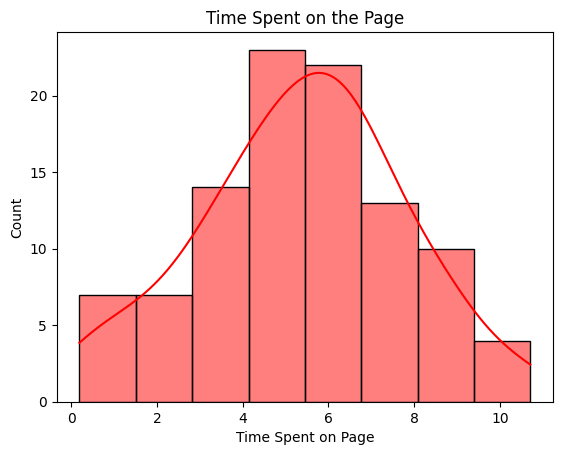

In [ ]:
sns.histplot(df['time_spent_on_the_page'], kde=True, color='red') # this code creates a histogram plot for the column for time spent on the page
plt.title('Time Spent on the Page') # this code sets the title of the histogram plot as specified in the parenthesis.
plt.xlabel('Time Spent on Page') # this code sets the label on the x axis as 'Time Spent on Page'
plt.ylabel('Count') # this code sets the label on the y axis as 'Count'.
plt.show() # this code displays the histogram plot.

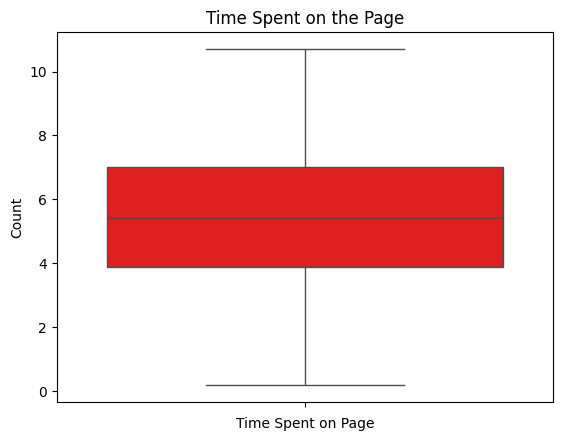

In [ ]:
sns.boxplot(df['time_spent_on_the_page'], color='red') # this code creates a box plot for the column for time spent on the page
plt.title('Time Spent on the Page') # this code sets the title of the box plot as specified in the parenthesis.
plt.xlabel('Time Spent on Page') # this code sets the label on the x axis as 'Time Spent on Page'
plt.ylabel('Count') # this code sets the label on the y axis as 'Count'.
plt.show() # this code displays the box plot.

#### Observations:

* *The distribution of values for 'time spent on the page' appears to be a normal distribution.*

* *The boxplot shows no outliers in the data.*




### **Categorical Data**

#### **Group**

In [ ]:
df['group'].value_counts() # this code checks and returns the frequency of each unique value in the Group column

,count
group,
control,50
treatment,50


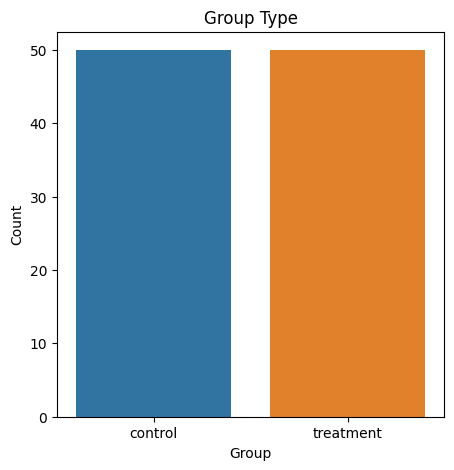

In [ ]:
plt.figure(figsize=(5,5)) #this code create a plot with the size 5,5.
sns.countplot(x = 'group', data = df, hue = 'group') # this code creates a count plot using the group column of the dataframe 'df' with each bar having a different color.
plt.title('Group Type') # this code sets the title of the count plot as specified in the parenthesis.
plt.xlabel('Group') # this code sets the label on the x axis as 'Group'
plt.ylabel('Count') # this code sets the label on the y axis as 'Count'.
plt.show() # this code displays the count plot.

#### Observations:

* *There are equal number of users in both the treatment and control groups.*


#### **Landing Page**

In [ ]:
df['landing_page'].value_counts() # this code checks and returns the frequency of each unique value in the Landing Page column

,count
landing_page,
old,50
new,50


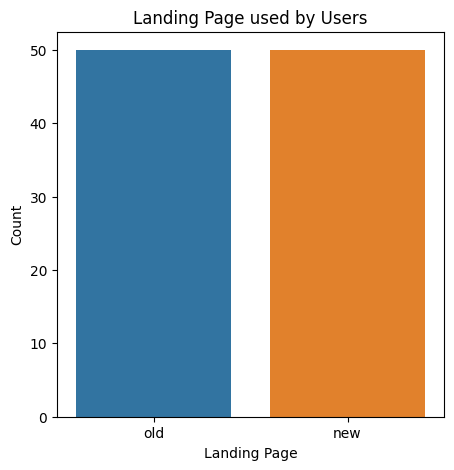

In [ ]:
plt.figure(figsize=(5,5)) #this code create a plot with the size 5,5.
sns.countplot(x = 'landing_page', data = df, hue = 'landing_page') # this code creates a count plot using the landing page column of the dataframe 'df' with each bar having a different color.
plt.title('Landing Page used by Users') # this code sets the title of the count plot as specified in the parenthesis.
plt.xlabel('Landing Page') # this code sets the label on the x axis as 'Landing Page'
plt.ylabel('Count') # this code sets the label on the y axis as 'Count'.
plt.show() # this code displays the count plot.

#### Observations:

* *Equal number of users visited the old and new landing pages.*

#### **Converted**

In [ ]:
df['converted'].value_counts(normalize=True) # this code returns the percentage of each unique value in the Converted column

,proportion
converted,
yes,0.54
no,0.46


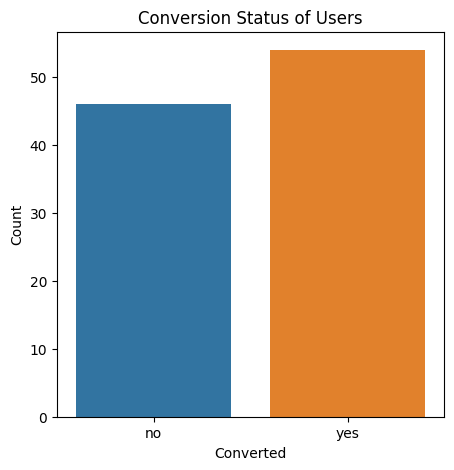

In [ ]:
plt.figure(figsize=(5,5)) #this code create a plot with the size 5,5.
sns.countplot(x = 'converted', data = df, hue = 'converted') # this code creates a count plot using the converted column of the dataframe 'df' with each bar having a different color.
plt.title('Conversion Status of Users') # this code sets the title of the count plot as specified in the parenthesis.
plt.xlabel('Converted') # this code sets the label on the x axis as 'Converted'
plt.ylabel('Count') # this code sets the label on the y axis as 'Count'.
plt.show() # this code displays the count plot.

#### Observations:

* *More users converted.*

* *54 users, (correcponding to 54% of the total number of users) converted while 46 users (corresponding to 46% of the total number of users) did not convert.*



#### **Language Preferred**

In [ ]:
df['language_preferred'].value_counts(normalize=True) # this code returns the percentage of each unique value in the Language Preferred column

,proportion
language_preferred,
Spanish,0.34
French,0.34
English,0.32


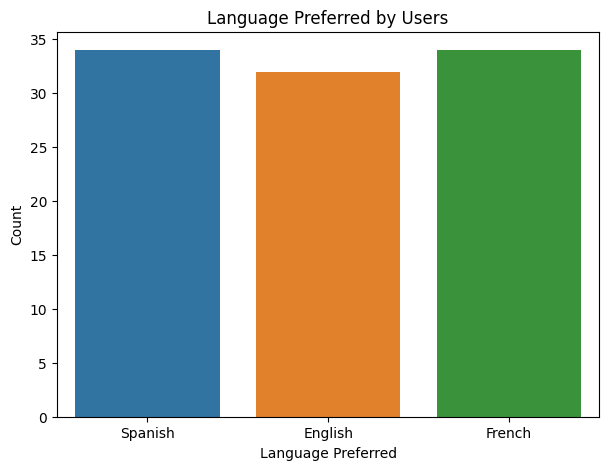

In [ ]:
plt.figure(figsize=(7,5)) #this code create a plot with the size 7,5.
sns.countplot(x = 'language_preferred', data = df, hue = 'language_preferred') # this code creates a count plot using the language preferred column of the dataframe 'df' with each bar having a different color.
plt.title('Language Preferred by Users') # this code sets the title of the count plot as specified in the parenthesis.
plt.xlabel('Language Preferred') # this code sets the label on the x axis as 'Language Preferred'
plt.ylabel('Count') # this code sets the label on the y axis as 'Count'.
plt.show() # this code displays the count plot.

#### Observations:

* *There were three languages for the users to choose from - English, French, Spanish.*

* *34% preferred Spanish and French and 32% preferred English.*

## **Bivariate Analysis**

#### **Group and Time Spent on Page**

In [ ]:
df.groupby('group')['time_spent_on_the_page'].mean() # this code returns the mean of the time spent on the page for each group

,time_spent_on_the_page
group,
control,4.5324
treatment,6.2232


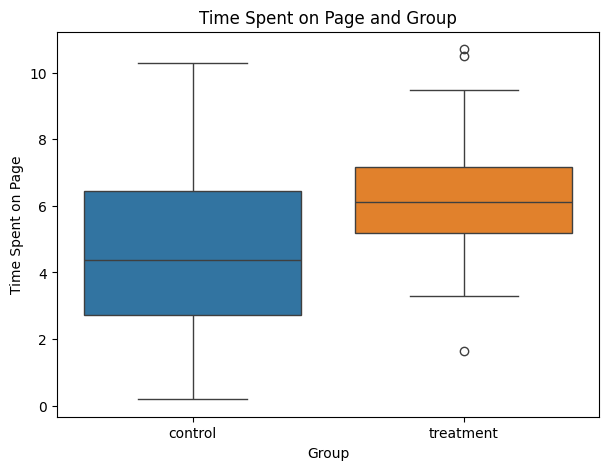

In [ ]:
plt.figure(figsize=(7,5)) #this code create a plot with the size 7,5.
sns.boxplot(x = 'group', y = 'time_spent_on_the_page', data = df, hue = 'group') #this code creates a boxplot of the group and time spent on the page
plt.title('Time Spent on Page and Group') # this code sets the title of the box plot as specified in the parenthesis.
plt.xlabel('Group') # this code sets the label on the x axis as 'Group'
plt.ylabel('Time Spent on Page') # this code sets the label on the y axis as 'Time Spent on Page'.
plt.show() # this code displays the box plot.

#### Observations:

* *There is a significant difference in time spent on the page between the treatment and the control groups.*

  * *Users in the treatment group spent more time on average (6.2 minutes) on the page than users in the control group (4.5 minutes).*

  * *The least amount of time spent on the page by the treatment group is about 3 minutes.*
  
  * *Comparatively, the least amount of time spent on the page by the control group is less than 1 minute.*

* *There are outliers in the treatment group while the control group has no outliers.*


#### **Landing Page and Time Spent on Page**

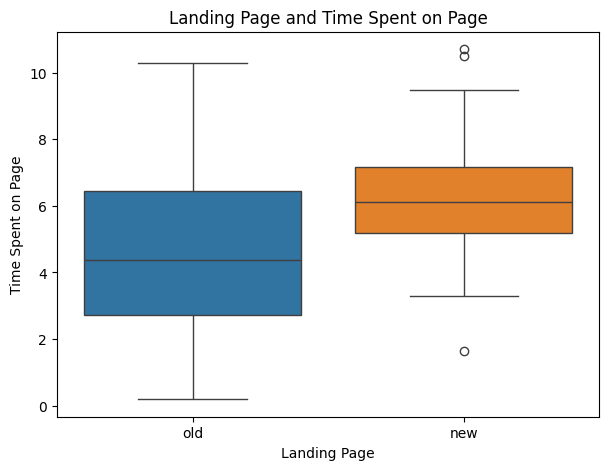

In [ ]:
plt.figure(figsize=(7,5)) #this code create a plot with the size 7,5.
sns.boxplot(x = 'landing_page', y = 'time_spent_on_the_page', data = df, hue = 'landing_page') #this code creates a boxplot of the landing page and time spent on the page
plt.title('Landing Page and Time Spent on Page') # this code sets the title of the box plot as specified in the parenthesis.
plt.xlabel('Landing Page') # this code sets the label on the x axis as 'Landing Page'
plt.ylabel('Time Spent on Page') # this code sets the label on the y axis as 'Time Spent on Page'.
plt.show() # this code displays the box plot.

#### Observations:

* *There is a difference in time spent on the landing page between the two groups.*

  * *Users who visited the new landing page spent more time than the users who visited the old landing page.*

* *There are outliers in the group that visited the new landing page, while the group that visited the old landing page has no outliers.*

#### **Group and Conversion Type**

In [ ]:
df['converted'].groupby(df['group']).value_counts() # this code checks and returns the frequency of each value in the Converted column by grouping them according to conversion type and group

group      converted
control    no           29
           yes          21
treatment  yes          33
           no           17
Name: count, dtype: int64

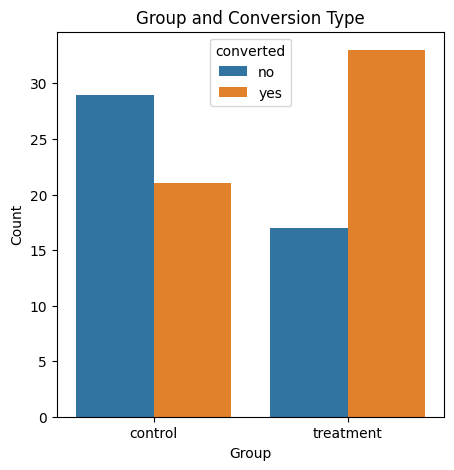

In [ ]:
plt.figure(figsize=(5,5)) #this code create a plot with the size 5,5.
sns.countplot(x = 'group', data = df, hue = 'converted') # this code creates a count plot using the data in the converted and group columns.
plt.title('Group and Conversion Type') # this code sets the title of the count plot as specified in the parenthesis.
plt.xlabel('Group') # this code sets the label on the x axis as 'Converted'
plt.ylabel('Count') # this code sets the label on the y axis as 'Count'.
plt.show() # this code displays the count plot.

#### Observations:

* *More users in the treatment group (33) converted as compared to those in the control group (21).*

* *More users in the control group (29) did not convert.*

#### **Conversion Type and Time Spent on Page**

In [ ]:
df.groupby('converted')['time_spent_on_the_page'].mean() # this code returns the mean of the time spent on the page for each group

,time_spent_on_the_page
converted,
no,3.915870
yes,6.623148


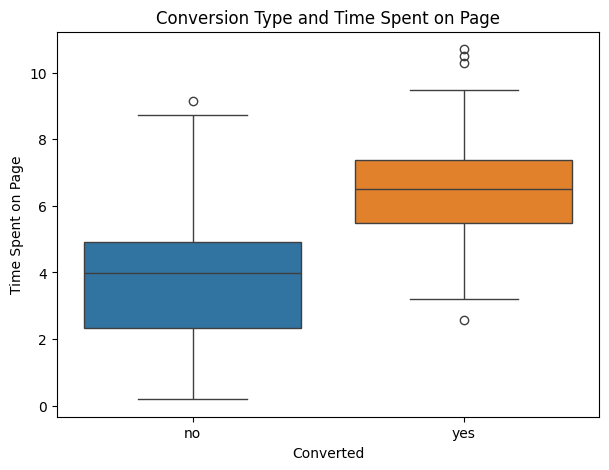

In [ ]:
plt.figure(figsize=(7,5)) #this code create a plot with the size 7,5.
sns.boxplot(x = 'converted', y = 'time_spent_on_the_page', data = df, hue = 'converted') #this code creates a boxplot of the conversion type and time spent on the page
plt.title('Conversion Type and Time Spent on Page') # this code sets the title of the box plot as specified in the parenthesis.
plt.xlabel('Converted') # this code sets the label on the x axis as 'Converted'
plt.ylabel('Time Spent on Page') # this code sets the label on the y axis as 'Time Spent on Page'.
plt.show() # this code displays the box plot.

#### Observations:

* *There is a significant difference in time spent on the landing page between the two groups.*

  * *Users who converted spent more time on the page than the users who did not convert.*

  * *The average time spent on the page by users who converted is about 6.6 minutes while that of those who did not convert is about 3.9 minutes.*

* *There are outliers in both groups. However, there are more outliers in the group of users that converted versus those that did not convert.*

#### **Group and Preferred Language**

In [ ]:
df['language_preferred'].groupby(df['group']).value_counts() # this code checks and returns the frequency of each value in the Language Preferred column by grouping them according to treatment or control group

group      language_preferred
control    French                17
           Spanish               17
           English               16
treatment  French                17
           Spanish               17
           English               16
Name: count, dtype: int64

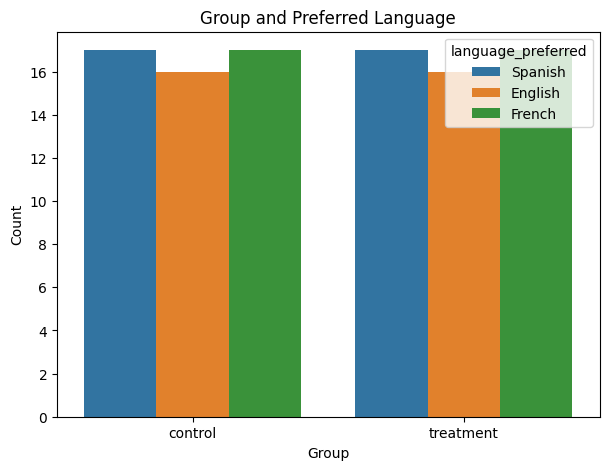

In [ ]:
plt.figure(figsize=(7,5)) #this code create a plot with the size 7,5.
sns.countplot(x = 'group', data = df, hue = 'language_preferred') # this code creates a count plot using the data in the language preferred and group columns
plt.title('Group and Preferred Language') # this code sets the title of the count plot as specified in the parenthesis.
plt.xlabel('Group') # this code sets the label on the x axis as 'Group
plt.ylabel('Count') # this code sets the label on the y axis as 'Count'.
plt.show() # this code displays the count plot.

#### Observations:

* *There is no significant difference in preferred language among both the treatment and control groups.*

#### **Preferred Language and Time Spent on Page**

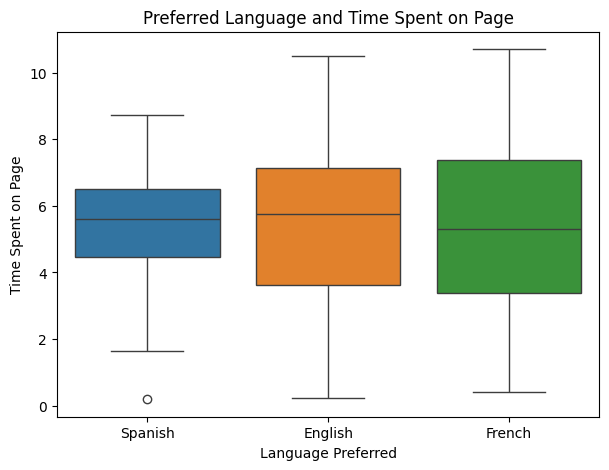

In [ ]:
plt.figure(figsize=(7,5)) #this code create a plot with the size 7,5.
sns.boxplot(x = 'language_preferred', y = 'time_spent_on_the_page', data = df, hue = 'language_preferred') #this code creates a boxplot of the preferred language and time spent on the page
plt.title('Preferred Language and Time Spent on Page') # this code sets the title of the box plot as specified in the parenthesis.
plt.xlabel('Language Preferred') # this code sets the label on the x axis as 'Language Preferred
plt.ylabel('Time Spent on Page') # this code sets the label on the y axis as 'Time Spent on Page'.
plt.show() # this code displays the box plot.

In [ ]:
df.groupby('language_preferred')['time_spent_on_the_page'].mean() # this code returns the mean of the time spent on the page for each group

,time_spent_on_the_page
language_preferred,
English,5.559062
French,5.253235
Spanish,5.331765


#### Observations:

* *There is little difference in the time spent on the landing page between the three groups.*

  * *From the boxplot, the users in the three language groups seem to have close to similar medians and minimum values.*
  
  * *The average time spent on the page by users who preferred English is 5.6 minutes, those who preferred French is 5.2 minutes and those who preferred Spanish is 5.3 minutes.*

* *There are outliers in the group that preferred Spanish. There are no outliers in the group that preferred French and English.*

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

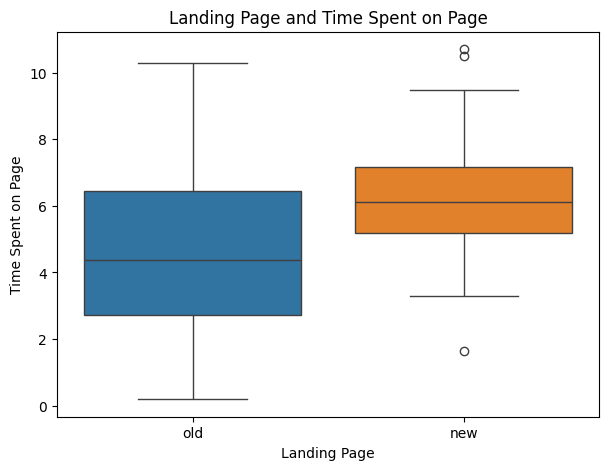

In [ ]:
plt.figure(figsize=(7,5)) #this code create a plot with the size 7,5.
sns.boxplot(x = 'landing_page', y = 'time_spent_on_the_page', data = df, hue = 'landing_page') #this code creates a boxplot of the landing page and time spent on the page
plt.title('Landing Page and Time Spent on Page') # this code sets the title of the box plot as specified in the parenthesis.
plt.xlabel('Landing Page') # this code sets the label on the x axis as 'Landing Page'
plt.ylabel('Time Spent on Page') # this code sets the label on the x axis as 'Time Spent on Page'
plt.show() # this code displays the box plot.

#### Observations:

* *From the boxplot above, users spent more time on the new landing page than on the old landing page.*


### Step 1: Define the null and alternate hypotheses

$H_0$: The mean time spent on the new landing page ($μ_1$) is equal to the mean time spent on the old landing page ($μ_2$).

$H_0$: $μ_1$ = $μ_2$

-----------------------------------
$H_a$: The mean time spent on the new landing page ($μ_1$) is greater than the mean time spent on the old landing page ($μ_2$).

$H_a$: $μ_1$ > $μ_2$

### Step 2: Select Appropriate test

The appropriate test to be used is the **two sample independent t-test**. This is because, the question involves testing the means of two independent populations (users who visited the new versus the old landing page). Additionally, the standard devations for the two populations are not yet known.

### Step 3: Decide the significance level

The significance level ($\alpha) $ = 0.05

### Step 4: Collect and prepare data

In [ ]:
time_spent_new = df[df['landing_page'] == 'new']['time_spent_on_the_page'] #this code creates a dataframe (from the original dataframe) of users who visited the new landing page.
time_spent_old = df[df['landing_page'] == 'old']['time_spent_on_the_page'] #this code creates a dataframe (from the original dataframe) of users who visited the old landing page.

In [ ]:
round(time_spent_new.std(),2) # this code returns the standard deviation of the time spent on the new landing page and rounds the value to 2 decimal places.

1.82

In [ ]:
round(time_spent_old.std(),2) # this code returns the standard deviation of the time spent on the old landing page and rounds the value to 2 decimal places.

2.58

#### Observations:

* *The standard deviation for the time spent on the new page is 1.82 while the standard deviation for the time spent on the old page is 2.58.*

### Step 5: Calculate the p-value

In [ ]:
from scipy.stats import ttest_ind # this code imports the ttest_ind function from the scipy library.

test_stat, p_value = ttest_ind(time_spent_new, time_spent_old, equal_var=False, alternative='greater') #this code calculates the p-value using the ttest_ind function
p_value

np.float64(0.0001392381225166549)

#### Observation:

* *The p-value is 0.0001392381225166549*

### Step 6: Compare the p-value with $\alpha$

In [ ]:
if p_value < 0.05:
  print('Reject the null hypothesis')
else:
  print('Fail to reject the null hypothesis')

#this code compares the p-value and alpha and rejects or fails to reject the null hypothesis based on the output of the comparison.

Reject the null hypothesis


### Step 7:  Draw inference

Based on the question, this test assessed whether users spent more time on the new landing page than on the old landing page.

This was a one-tailed t-test performed at a significance level of 5%.

The p-value found was 0.0001392381225166549 which is lower than 0.05. Hence the null hypothesis was rejected.

Based on this, the statistical evidence is enough to conclude that users who visited the new landing page spent more time than users who visited the old landing page.

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

### Visual Analysis

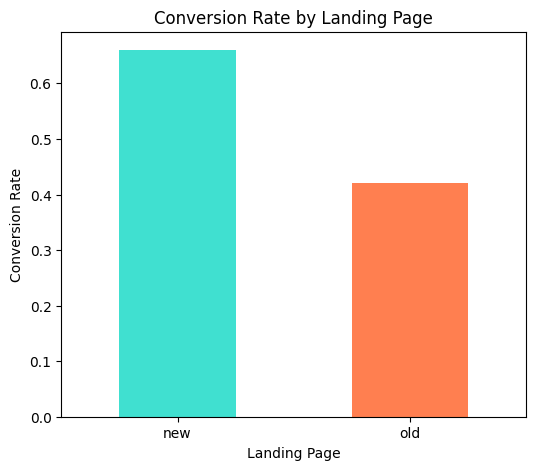

In [ ]:
conversion_rates = df.groupby('landing_page')['converted'].value_counts(normalize=True).unstack() # this codes groups the dataframe according to the landing page column, checks the frenquency of each unique value in the converted column and reshapes the dataframe by placing the landing page as index.
conversion_rates['yes'].plot(figsize=(6,5), kind='bar', color=['turquoise','coral']) # this code creates a bar chart of the conversion rates for users who converted or not and sets the color as specified
plt.title('Conversion Rate by Landing Page') # this code sets the title of the box plot as specified in the parenthesis.
plt.xlabel('Landing Page') # this code sets the label on the x axis as 'Landing Page'
plt.ylabel('Conversion Rate') # this code sets the label on the y. axis as 'Conversion Rate'
plt.xticks(rotation=0) # this code horizontally rotates the x-axis labels
plt.show() # this code displays the barplot

#### Observation:

* *From the bar plot, the conversion rate for users who visited the new landing page is greater as compared to the conversion rate for users who visited the old landing page.*

### Null and Alternate Hypothesis

$H_0$: The conversion rate for the new landing page ($p_1$) is equal to the conversion rate for the old landing page ($p_2$).

$H_0$: $p_1$ = $p_2$

-----------------------------------
$H_a$: The conversion rate for the new landing page ($p_1$) is greater than the conversion rate for the old landing page ($p_2$).

$H_a$: $p_1$ > $p_2$

### Appropriate Test to be used

The appropriate test to be used is the **one-tailed z-test**.
The question involves comparing two proportions (conversion rates) from two independent populations (new landing page and old landing page).

### Significance Level

The significance level ($\alpha) $ = 0.05

### Data Collection

In [ ]:
df['group'].value_counts() # this code checks and returns the frequency of each unique value in the Group column

,count
group,
control,50
treatment,50


In [ ]:
print(df[df['group'] == 'treatment']['converted'].value_counts()['yes']) # this code checks and returns the frequency of users in the treatment group who converted.
print(df[df['group'] == 'control']['converted'].value_counts()['yes']) # this code checks and returns the frequency of users in the control group who converted.

33
21


#### Observations:

* *The total number of users (100) in the entire experiment where divided equally (50 each) in the treatment and control groups.*

* *The users in the control group visited the old landing page while the users in the treatment group visited the new landing page.*

* *33 users in the treatment group converted after visiting the new landing page.*

* *21 users in the control group converted after visiting the old landing page.*

### The p-value

In [ ]:
from statsmodels.stats.proportion import proportions_ztest # this code imports the proportions_ztest function from the statsmodels library.

test_stat, p_value = proportions_ztest(count=[33,21], nobs=[50,50], alternative='larger') #this code calculates the p-value using the proportions_ztest function
print(p_value)

0.008026308204056278


#### Observation:

* *The p-value is 0.008026308204056278*

### Compare p-value and $\alpha$

In [ ]:
if p_value < 0.05:
  print('Reject the null hypothesis')
else:
  print('Fail to reject the null hypothesis')

#this code compares the p-value and alpha and rejects or fails to reject the null hypothesis based on the output of the comparison.

Reject the null hypothesis


### Inference

Based on the question, this test assessed the conversion of users who visited the new landing page versus users who visited the old landing page.

This was a one-tailed z-test performed at a significance level of 5%.

The p-value found was 0.008026308204056278 which is lower than 0.05. Hence the null hypothesis was rejected.

Based on this statistical evidence, it is concluded that the conversion rate is higher for users who visited the new landing page than users who visited the old landing page.

## 3. Is the conversion and preferred language independent or related?

### Visual Analysis

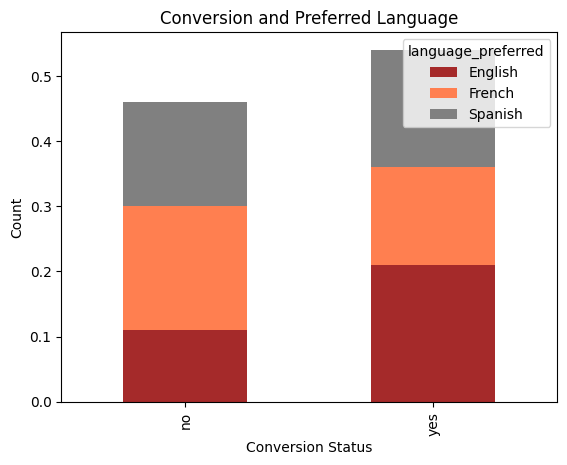

In [ ]:
pd.crosstab(df['converted'], df['language_preferred'], normalize=True).plot(kind='bar', stacked=True, color=['brown','coral','grey']) # this code creates a stacked barplot of the proportion of users for each combination of conversion status and preferred language
plt.title('Conversion Rate and Preferred Language') # this code sets the title of the box plot as specified in the parenthesis.
plt.xlabel('Conversion Status') # this code sets the label on the x axis as 'Language Preferred'
plt.ylabel('Count') # this code creates the label on the y axis as 'Count'
plt.show() #this code displays the stacked barplot

#### Observation:

* *From the stacked bar plot, the conversion rate was highest for users who selected English.*

* *Additionally, the conversion rate was least for users who selected English.*

### Null and Alternate Hypothesis

$H_0$: The conversion status is independent of the preferred language.

$H_a$: The conversion status is not independent of the preferred language.

### Appropriate Test to use

The appropriate test to be used is the **Chi-square test** of independence.
The question involves assessing whether two categorial variables (conversion and preferred langauge) are independent.

### Significance Level

The significance level ($\alpha)$ = 0.05

### Data Collection

In [ ]:
contingency_table = pd.crosstab(df['converted'], df['language_preferred']) # this code creates a contingency table using the converted and language preferred columns.
contingency_table

language_preferred,English,French,Spanish
converted,,,
no,11,19,16
yes,21,15,18


### The p-value

In [ ]:
from scipy.stats import chi2_contingency # this code imports the chi2_contingency function from the scipy library.

p_value = chi2_contingency(contingency_table)[1] # this code calculates the p-value using the chi2_contingency function
print(p_value)

0.21298887487543447


####Observation:
* *The p-value is 0.21298887487543447.*

### Comparison of p-value and $\alpha$

In [ ]:
if p_value < 0.05:
  print('Reject the null hypothesis')
else:
  print('Fail to reject the null hypothesis')

#this code compares the p-value and alpha and rejects or fails to reject the null hypothesis based on the output of the comparison.

Fail to reject the null hypothesis


### Inference

Based on the question, this test assessed the independence between the conversion status and the preferred language of the users.

The Chi-square test of independence was performed at a significance level of 5%.

The p-value found was 0.21298887487543447 which is greater than 0.05. Hence I failed to reject the null hypothesis.

Based on this, there is no significant evidence to concluded that the conversion status is dependent on the langauge preferred.


## 4. Is the time spent on the new page same for the different language users?

### Visual Analysis

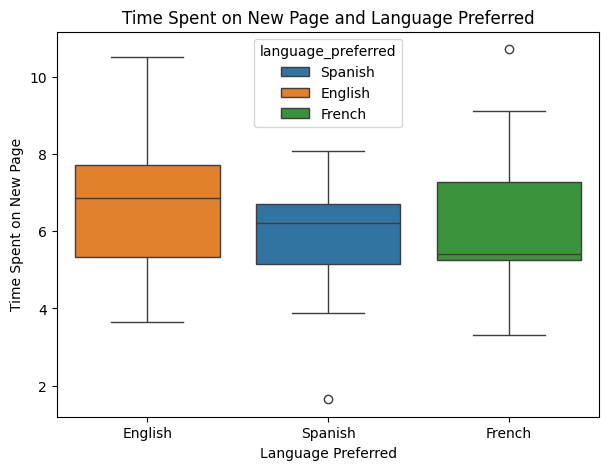

In [ ]:
df_new = df[df['landing_page'] == 'new'] #this code creates a dataframe (from the original dataframe) of users who visited the new landing page.

plt.figure(figsize=(7,5)) #this code create a plot with the size 7,5.
sns.boxplot(x = df_new['language_preferred'], y = df_new['time_spent_on_the_page'], data = df, hue = 'language_preferred') #this code creates a boxplot of the preferred language and time spent on the page and differentiates each language by color
plt.title('Time Spent on New Page and Language Preferred') # this code sets the title of the box plot as specified in the parenthesis.
plt.xlabel('Language Preferred') # this code sets the label on the x axis as 'Language Preferred'
plt.ylabel('Time Spent on New Page') #this code sets the label on the y axis as 'Time Spent on New Page'
plt.show() #this code displays the boxplot

In [ ]:
df_new.groupby('language_preferred')['time_spent_on_the_page'].mean() # this code returns the mean of the time spent on the new page for each language

,time_spent_on_the_page
language_preferred,
English,6.663750
French,6.196471
Spanish,5.835294


#### Observation:

* *From the boxplot, the time spent on the new page does not seem very different for all three languages. However, this would have to be investigated with further analysis*


* *From the mean values, users who chose English spent more time on average than the other languages.*

### Null and Alternate Hypothesis

$H_0$: The mean time spent on the new page is equal for all languages.

$H_a$: The mean time spent on the new page is not equal for all languages.

### Appropriate Test

The appropriate test is the **One-way Analysis of Variance (ANOVA)**. The question involves assessing three different groups (English, French and Spanish users)

### Significance Level

The significance level ($\alpha)$ = 0.05

### Collect Data

In [ ]:
time_spent_english = df_new[df_new['language_preferred'] == 'English']['time_spent_on_the_page'] #this code creates a dataframe (from the original dataframe) of users who chose English.
time_spent_french = df_new[df_new['language_preferred'] == 'French']['time_spent_on_the_page'] #this code creates a dataframe (from the original dataframe) of users who chose French.
time_spent_spanish = df_new[df_new['language_preferred'] == 'Spanish']['time_spent_on_the_page'] #this code creates a dataframe (from the original dataframe) of users who chose Spanish.

### The p-value

In [ ]:
from scipy.stats import f_oneway # this code imports the f_oneway function from the scipy library.

test_stat, p_value = f_oneway(time_spent_english, time_spent_french, time_spent_spanish) #this code calculates the p-value using the f_oneway function
print(p_value)

0.43204138694325955


### Comparison of p-value and $\alpha$

In [ ]:
if p_value < 0.05:
  print('Reject the null hypothesis')
else:
  print('Fail to reject the null hypothesis')

#this code compares the p-value and alpha and rejects or fails to reject the null hypothesis based on the output of the comparison.

Fail to reject the null hypothesis


### Inference

Based on the question, this test assessed the difference between users who preferred English, French and Spanish.

The One-way Analysis of Variance (ANOVA) test was performed at a significance level of 5%.

The p-value found was 0.43204138694325955 which is greater than 0.05. Hence I failed to reject the null hypothesis.

Based on this, there is little statistical evidence to conclude that there is a significant difference in the mean times for the three different language groups.

## Conclusion and Business Recommendations

Based on the analysis performed above, it was found that:

* On average, users in the treatment group spent about 6.2 minutes on the landing page and users in the control group spent about 4.5 minutes on the landing page. Since the treatment group visited the new page and the control group visited the old page, it is evident that the users spent more time on the new landing page than on the old landing page.

* The conversion rate was higher for users who visited the new landing page.

* There was no significant evidence to conclude that the conversion status is dependent on the langauge preferred.

* There was little statistical evidence to conclude that there is a significant difference in the mean times for the three different language groups.


Essentially,
  * The **new landing page** is capable of attracting customers, keeping them engaged and increasing customer subscription. It seems to boost user experience since they spent more time on the page and increases the likelihood of users becoming subscribers.

  It is recomended that E-new Express changes the old landing page to the **new landing page**. In addition, it is recommended that E-new Express become adaptable and dynamic in order to respond appropraitely to the changing trends in technological advancements. Also, periodic surveys on user experience, statisfaction and feedback will improve their services, retain and attract more subcribers.

  * Language is essential in customer satisfaction and ensuring inclusivity. Although English users had higher conversion rates, the evidence did not show any strong relationship between language and user engagement and subscription. Regardless, for E-new Express to expand it's business, bridging the language barrier is essential.
  
  It is recommended that further studies is conducted to understand the different expectations of the users based on their language preferrence using a statistically significant sample size (larger sample space from difference places).

___

This project involved analyzing A/B test data for E-news Express to assess the effectiveness of a new landing page. The analysis was conducted using Python, primarily utilizing libraries such as pandas for data manipulation, matplotlib and seaborn for data visualization, and scipy and statsmodels for statistical hypothesis testing (t-tests, z-tests, and Chi-square tests).

The project focused on exploring the dataset, performing univariate and bivariate analyses, and conducting hypothesis tests to address four key business questions:
1.  Comparing time spent on new vs. old landing pages.
2.  Comparing conversion rates for new vs. old landing pages.
3.  Assessing the independence of conversion status and preferred language.
4.  Evaluating if time spent on the new page varies among different language users.

The findings were used to provide business recommendations regarding the adoption of the new landing page and considerations for language preferences.